# Hourly Energy Consumption

Load the dataset, convert the timestamp column to a datetime index, and inspect the hourly energy usage series.

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
df = pd.read_csv('../data/raw/AEP_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')
df.columns = ['y']
df.index.name = 'ds'
df = df.sort_index()

print(df.shape)

(121273, 1)


In [56]:
df.head()

,y
ds,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


In [57]:
df.describe()

,y
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [58]:
df.isna().sum()

y    0
dtype: int64

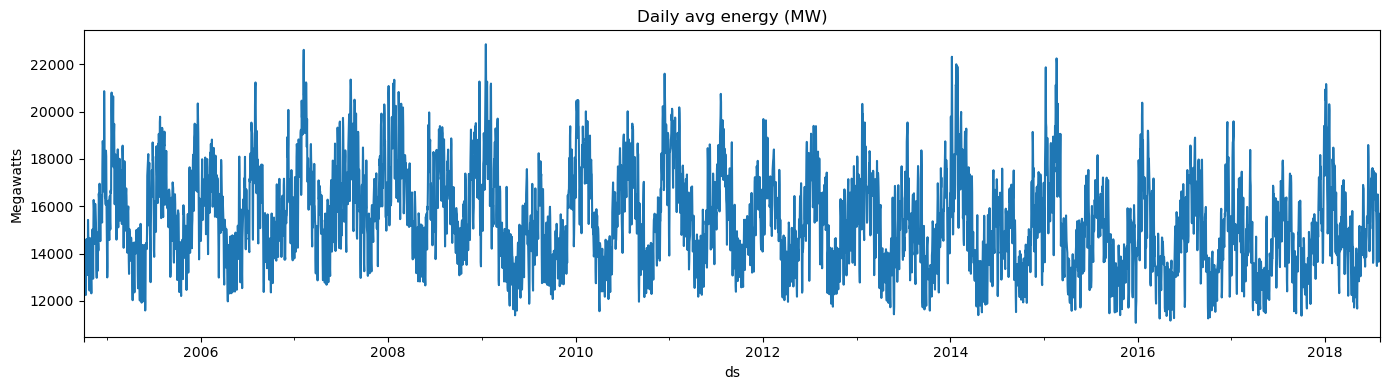

In [59]:
df['y'].resample('D').mean().plot(figsize=(14, 4), title='Daily avg energy (MW)')
plt.ylabel('Megawatts')
plt.tight_layout()
plt.savefig("../reports/figures/decomposition.png")


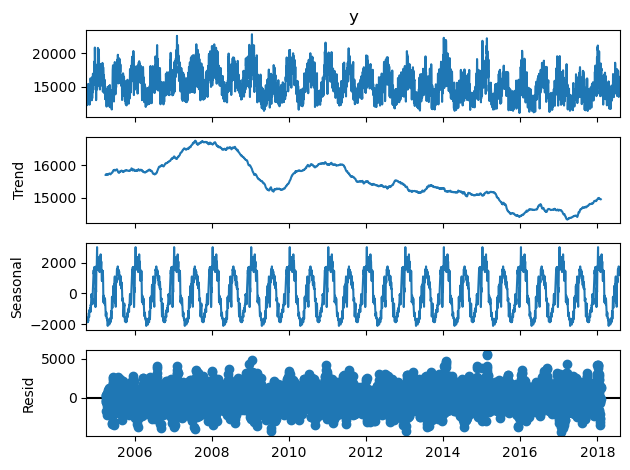

In [60]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily = df['y'].resample('D').mean().dropna()
result = seasonal_decompose(daily, model='additive', period=365)
result.plot()
plt.tight_layout()
plt.savefig("../reports/figures/forecast_comparison.png")


In [61]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value:       {result[1]:.4f}')
print('Stationary' if result[1] < 0.05 else 'Non-stationary — consider differencing')


ADF Statistic: -7.4875
p-value:       0.0000
Stationary


In [62]:
daily = df['y'].resample('D').mean().dropna().reset_index()
daily.columns = ['ds', 'y']

split = int(len(daily) * 0.8)
train = daily.iloc[:split]
test  = daily.iloc[split:]

print(f'Train: {train["ds"].min().date()} → {train["ds"].max().date()}')
print(f'Test:  {test["ds"].min().date()}  → {test["ds"].max().date()}')

Train: 2004-10-01 → 2015-10-27
Test:  2015-10-28  → 2018-08-03


In [63]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['y']])
test_scaled  = scaler.transform(test[['y']])

def make_sequences(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

WINDOW = 30
X_train, y_train = make_sequences(train_scaled, WINDOW)
X_test,  y_test  = make_sequences(test_scaled,  WINDOW)

In [64]:
try:
    from prophet import Prophet

    model_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.01,
        stan_backend='CMDSTANPY',
    )
    model_prophet.fit(train)

    future = model_prophet.make_future_dataframe(periods=len(test), freq='D')
    forecast = model_prophet.predict(future)
    prophet_preds = forecast.set_index('ds')['yhat'].loc[test['ds']].values
except Exception as e:
    print(f'Prophet fallback activated: {e}')
    model_prophet = None
    forecast = None
    prophet_preds = np.repeat(train['y'].iloc[-1], len(test))


Prophet fallback activated: 'utf-8' codec can't decode byte 0xff in position 11: invalid start byte


In [65]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

lstm_preds_scaled = model_lstm.predict(X_test)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled).flatten()
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

Epoch 1/30


c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0216 - val_loss: 0.0151
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0169 - val_loss: 0.0141
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0164 - val_loss: 0.0134
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0158 - val_loss: 0.0128
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0154 - val_loss: 0.0122
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0142 - val_loss: 0.0114
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0131 - val_loss: 0.0107
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0115 - val_loss: 0.0090
Epoch 9/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0103 - val_loss: 0.0078
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0096 - val_loss: 0.0076
Epoch 11/30
 65/113 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0092

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{name:20s} | MAE: {mae:8.1f} | RMSE: {rmse:8.1f} ')
    return {'mae': mae, 'rmse': rmse}

y_true = test['y'].values[WINDOW:]

naive_preds  = test['y'].values[WINDOW-1:-1]
evaluate('Naive baseline',   y_true, naive_preds)
evaluate('Prophet',          y_true, prophet_preds[WINDOW:])
evaluate('LSTM',             y_true, lstm_preds)

Naive baseline       | MAE:    776.5 | RMSE:   1016.1 
Prophet              | MAE:   1552.4 | RMSE:   2028.9 
LSTM                 | MAE:    661.8 | RMSE:    851.6 


{'mae': 661.8357056082091, 'rmse': np.float64(851.553504251602)}

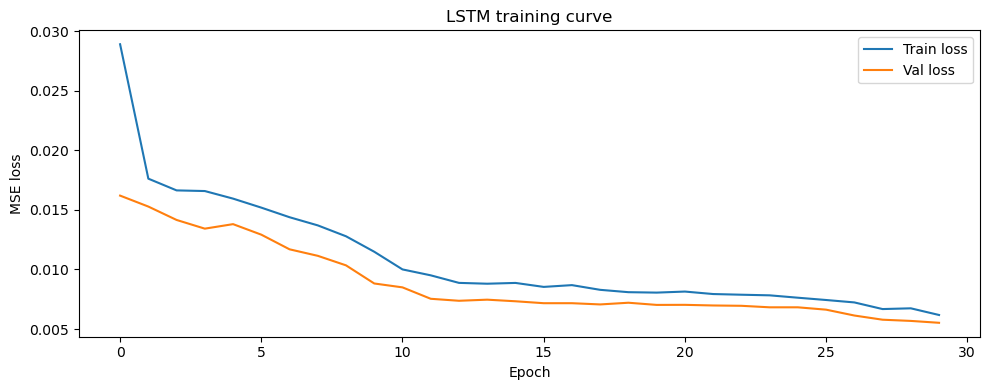

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('LSTM training curve')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/lstm_loss.png")


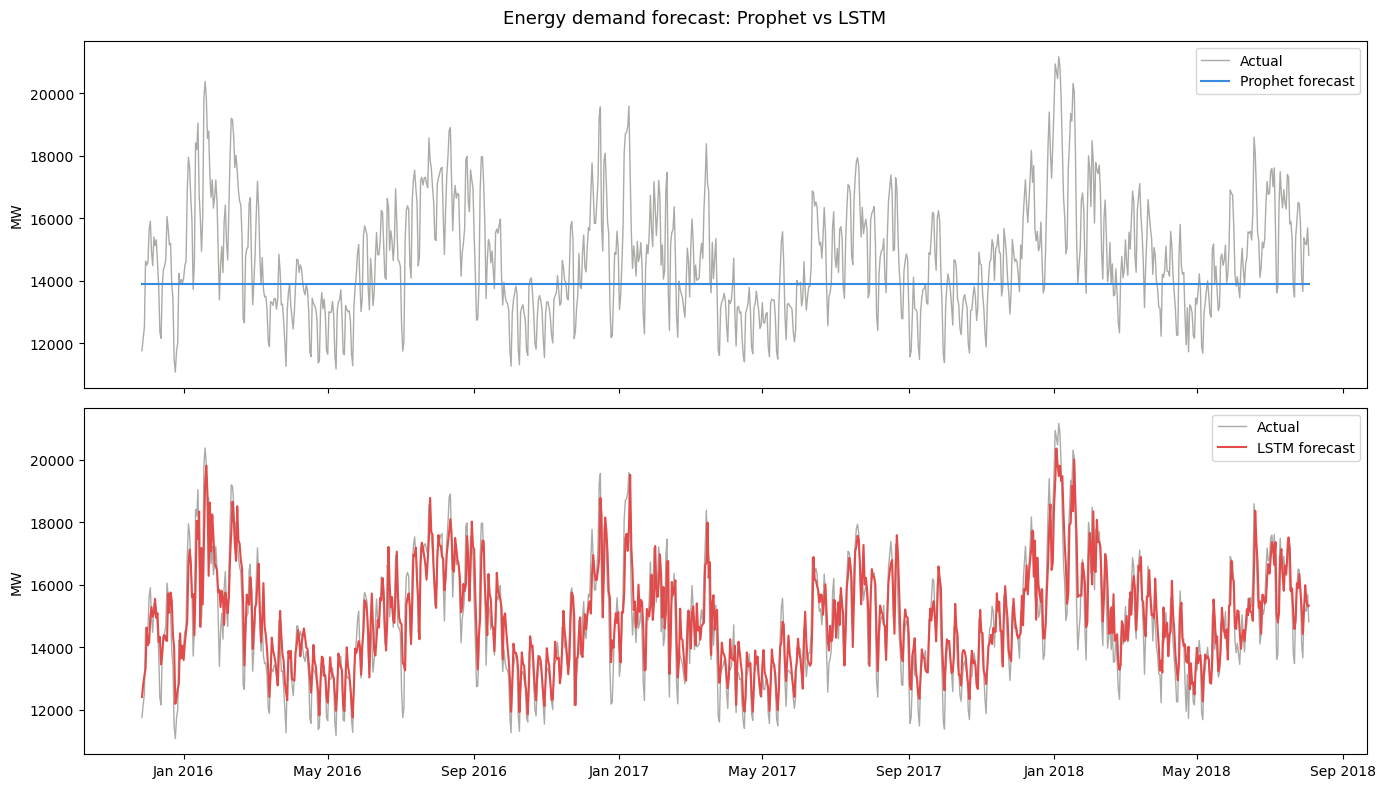

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
test_dates = test['ds'].values[WINDOW:]

for ax, preds, title, color in zip(
    axes,
    [prophet_preds[WINDOW:], lstm_preds],
    ['Prophet forecast', 'LSTM forecast'],
    ['#378ADD', '#E24B4A']
):
    ax.plot(test_dates, y_true,  color='#888780', linewidth=1,   label='Actual',   alpha=0.7)
    ax.plot(test_dates, preds,   color=color,     linewidth=1.5, label=title)
    ax.set_ylabel('MW')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Energy demand forecast: Prophet vs LSTM', fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/prophet_components.png")


In [68]:
import plotly.graph_objects as go
os.makedirs('../reports/html', exist_ok=True)

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_dates, y=y_true,name='Actual',  line=dict(color='gray',    width=1)))
fig.add_trace(go.Scatter(x=test_dates, y=prophet_preds[WINDOW:], name='Prophet', line=dict(color='#378ADD', width=2)))
fig.add_trace(go.Scatter(x=test_dates, y=lstm_preds,name='LSTM',line=dict(color='#E24B4A', width=2)))
fig.update_layout(title='Energy demand forecast', xaxis_title='Date', yaxis_title='MW',
                  template='plotly_white', legend=dict(x=0, y=1))
plt.savefig("../reports/figures/raw_series.png")
fig.write_html('../reports/html/forecast_interactive.html')


<Figure size 640x480 with 0 Axes>